<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/2_An%C3%A1lisis_Exploratorio_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**
---




# **2. Análisis Exploratorio de datos**

## 🎯 Manipulación de datos

## 🥇 Pandas


Una vez que se instaló la librería, **importar** en el entorno para comenzar a trabajar con ella. Ejecutar la siguiente instrucción:

In [ ]:
import pandas as pd # Importar pandas con el alias pd

`import` es una palabra reservada en Python, que se debe llamar para importar cualquier librería a utilizar. Esta es una forma.

Por otro lado, el alias acordado por la comunidad es `pd`, por lo que aquí se lo utiliza. Se asume como una práctica estándar para toda la documentación de Pandas.

### Estructuras de datos
Para comenzar a usar la librería, es importante familiarizarse con sus dos estructuras de datos principales:

* **Series**
* **DataFrame**


#### Series


La serie más simple se forma a partir de una lista de datos.


In [ ]:
s = pd.Series([4, 17, -51, 3], name='Serie A') # Crear serie a partir de una lista = [4, 17, -51, 3]

s # Mostrar

Como no especificamos un índice para los datos, se crea uno predeterminado que consta de los números enteros del $0$ al $N - 1$ (donde N es la cantidad de valores). Para el ejemplo la serie tiene una colección de $N=4$ valores, el nombre de la serie es *Serie A* y el indice es una colección de enteros de 0 a 3.

Para acceder a la colección de valores y al indice considerar los atributos de la serie `value` e `index` respectivamente:

In [ ]:
s.values # Acceder a la colección de valores

In [ ]:
s.index # Acceder a la colección de etiquetas. Indice


Si necesitas reforzar sobre las estructuras de datos en Python, mirar la notebook **Fundamentos para empezar en CD e IA** de este curso o clicar en [Estructura de datos de la documentación oficial de Python](https://docs.python.org/es/3/tutorial/datastructures.html).

📝 **Ejercicio**

Crea tu primera Serie desde la lista [0,'A','B', 4, 2] . Guardar la serie con el nombre de variable `tiposdedatos_s`.

```
tiposdedatos_s = ...
```



In [ ]:
# Ejercicio



**Haz doble click para ver la respuesta**

<!--
# Crear serie
tiposdedatos_s = pd.Series( [0,'A','B', 4, 2])

# Mostrar
tiposdedatos_s
 -->

A menudo se desea crear una serie con un índice que identifique cada punto de datos:


In [ ]:
s = pd.Series ([4, 17, -51, 3],
               name='Serie A',
               index=['d', 'b', 'a', 'c']) # Crear una serie indicando nombre e indice

s # Mostrar

In [ ]:
s.values # Atributo del objeto, valores almacenados en la serie

In [ ]:
s.index # Atributo del objeto, indice


In [ ]:
s['a'] # Seleccionar el elemento asociado al valor del indice 'a'


In [ ]:
s[['c', 'a', 'd']] # Seleccionar los elementos asociados a lista de valores del indice


In [ ]:
print('Serie original:\n', s) # Imprimir

s['d'] = 6 # Modificar el valor asociado al valor del indice 'd'

print('\nSerie modificada:\n', s)

Las operaciones de array de NumPy, también se aplican en serie, como el filtrado con operadores relacional, la multiplicación por escalar o la aplicación de funciones matemáticas, que preservan el vínculo índice-valor:

In [ ]:
s

In [ ]:
s[s > 0] # Filtrar los valores mayores a 0. Máscaras

In [ ]:
s * 2 # Multiplicar por escalar 2

In [ ]:
s.sum() # Sumar todos los valores. Funciona por ser valores numéricos

En este curso, no exploramos la librería NumPy pero si deseas hacerlo, clicar en [documentación oficial](https://numpy.org/doc/stable/index.html).

In [ ]:
import numpy as np # Importar librería de Numpy para usar sus funciones definidas
np.exp(s) # Función exponencial

Si tienes datos contenidos en un diccionario de Python, puedes crear una serie. En el ejemplo siguiente `superficie_s` es un objeto Serie creado a partir del *diccionario* `superficie_dict`, que se pasa como argumento a la función `Series()`.
Este diccionario de provincias tiene como clave las provincias de 'Buenos Aires', 'Córdoba', 'Salta','Tucumán' y 'La Rioja'.

Cuando solo se pasa el diccionario como argumento de la función, el índice de la serie resultante se forma con las claves del diccionario en el orden generado.

In [ ]:

superficie_dict = {'Buenos Aires': 305907.4,
                   'Córdoba': 164707.8, # Por cada nombre de provincia un valor de superficie [km²] asociado.
                   'Salta': 155340.5,
                   'Tucumán': 22592.1,
                   'La Rioja': 91493.7
                   }

superficie_s = pd.Series(superficie_dict) # Serie desde dict

superficie_s

  
 En el ejemplo siguiente, se crea un nuevo objeto Serie, `superficie_s2` en donde los datos también provienen del diccionario `superficie_dict`, pero el indice se especifíca. En este caso el indice se corresponde con la lista de etiqueta `provincia`.


In [ ]:

provincias = ['Buenos Aires', 'Córdoba', 'Salta', 'Misiones'] # Crear lista

superficie_s2 = pd.Series(
    superficie_dict, # los datos provienen de un diccionario
    index = provincias # Se especifica el indice mediante lista
    )

superficie_s2 # Mostrar

En este ejemplo, se creó una Serie de Pandas a partir de un diccionario y una lista de etiquetas. A diferencia de cuando se utiliza solo un diccionario (donde se incluyen automáticamente todas las claves).

Al agregar una lista de etiquetas se fuerza el orden y la selección de los elementos a incluir.En este ejemplo, Pandas buscó los valores correspondientes a las etiquetas especificadas en la lista. Encontró valores para tres de ellas en el diccionario `superficie_dict`, y los ubicó correctamente. Sin embargo, como no se encontró ningún valor para la provincia de 'Misiones', Pandas asignó el valor **NaN** (Not a Number), que se utiliza para representar valores faltantes en estructuras de datos.

El tema de valores faltantes lo abordaremos con más profundidad en un módulo específico. Por ahora, te adelantamos que existen dos funciones muy útiles para detectarlos en una Serie:

* isnull(): devuelve True si el valor es faltante.

* notnull(): devuelve True si el valor no es faltante.

In [ ]:
pd.isnull(superficie_s2) # Método del objeto DataFrame

In [ ]:
superficie_s2.isnull()

In [ ]:
pd.notnull(superficie_s2)

In [ ]:
superficie_s2.notnull()

#### DataFrame


Vamos a construir dos objetos series:

- `superficie_s`, a partir de un diccionario. Retomamos el ejemplo anterior.

- `Poblacion_s`, a partir de dos listas

Luego vamos a construir el DataFrame `provincia_df` a partir de las dos Series.

In [ ]:
superficie_dict = {
    'Buenos Aires': 305907.4, # Por cada nombre de provincia un valor de superficie [km²] asociado.
    'Córdoba': 164707.8,
    'Salta': 155340.5,
    'Tucumán': 22592.1,
    'La Rioja': 91493.7
    }


superficie_s = pd.Series(
    superficie_dict, # Agregar datos
    name='superficie' # Agregar el nombre a la serie
    )

superficie_s # Mostrar

In [ ]:
provincia_lista = ['Buenos Aires','Salta','Córdoba', 'Tucumán', 'La Rioja'] # Crear lista 1

provincia_pop = [17541141, 1424397, 3760450, 1694656, 393531] # Crear lista 2

poblacion_s = pd.Series(
    provincia_pop, # Indicar los datos de la lista 2
    index=provincia_lista, # Indicar el indice tomar la lista 1
    name='poblacion' # Nombrar la serie
    )

poblacion_s # Mostrar

In [ ]:
print('Colección de valores:', poblacion_s.values) # Atributos de la Serie poblacion_s
print('Colección de etiquetas (indice):', poblacion_s.index)

Para crear un DataFrame desde un diccionario, tener en cuenta que las claves son las etiquetas de las columnas y los valores son los valores de las colecciones asociadas. Para el ejemplo son los valores de las series creadas previamente.

In [ ]:
provincia_df = pd.DataFrame(
    {'Poblacion': poblacion_s,
     'Superficie_km2': superficie_s
    } # Indicar datos del diccionario que aquí se define
  ) # Crear Dataframe


In [ ]:
provincia_df

📝 **Ejercicio**

Crea tu primer DataFrame desde un diccionario. Llamar al objeto DataFrame con el nombre  `estudiantes_df`. Utilizar el siguiente código:

```
# Importar librería numpy para llamar a random
import numpy as np

# Diccionario est_d

est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [49, 26, 37, 40, 35],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}
```




In [ ]:
# Ejercicio



**Haz doble click para ver la respuesta**
<!--
# Importar librería numpy para llamar a random
import numpy as np

# Diccionario est_d

est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [49, 26, 37, 40, 35],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}

# Crear DataFrame
estudiantes_df = pd.DataFrame(est_d)

# Mostrar
estudiantes_df
-->

Las columnas de `provincia_df` tienen diferentes tipos de datos:


In [ ]:
provincia_df.dtypes # Llamar al atributo dtypes

🔎 **Nota**

En su mayor parte, Pandas utiliza arrays y tipos de datos de NumPy para las series o las columnas individuales de un DataFrame. NumPy ofrece compatibilidad con `float`, `int`, `bool`, `timedelta64[ns]` y `datetime64[ns]`. Para más información click en [dtypes en documentación oficial de Pandas](https://Pandas.pydata.org/docs/user_guide/basics.html#basics-dtypes) (inglés).

**Atributos y datos subyacentes de DataFrame**

In [ ]:
provincia_df.shape # Informar sobre la cantidad de filas y columnas

In [ ]:
provincia_df.index # Informar el índice (etiquetas de fila)

In [ ]:
provincia_df.columns # Informar las etiquetas de las columnas

In [ ]:
provincia_df.values # Informar los valores, N-array.


### Indexación y selección de datos
---


Cada columna en un `DataFrame` es una `Serie`. Para acceder a una columna :

In [ ]:
provincia_df['Poblacion'] # Acceder a una columna mediante etiqueta, ejemplo 'Poblacion'


In [ ]:
print('Valores de la serie', provincia_df['Poblacion'].values)
print('Suma de los valores de la serie' , provincia_df['Poblacion'].sum())


Otra forma, es llamando a la columna como atributo del objeto. Tener en cuenta el '.'

In [ ]:
provincia_df.Poblacion # Acceder mediante 'Objdf.etiqueta'

In [ ]:
provincia_df['Poblacion']['Buenos Aires']# Acceder a la columna cuya etiqueta es 'Poblacion' y fila cuya etiqueta es 'Buenos Aires' (ver indice del DataFrame)


Las filas también se pueden recuperar por posición o nombre mediante un par de métodos. Usando las posiciones y el método `iloc` o las etiquetas y el método `loc`.

`iloc` se basa principalmente en la posición de números enteros pero también se puede utilizar con un array booleano.

**Indexación de sola las filas**

In [ ]:
provincia_df.iloc[0] # Fila en la posicion 0. En este caso la fila es la asociada a Buenos Aires

In [ ]:
provincia_df.iloc[[0,3]] # Acceder a una lista de filas, filas de la posición 0 y posición 3


In [ ]:
provincia_df.iloc[:3:] # Acceder a las filas mediante corte (slice)  [ini:fin:pasos]


In [ ]:
provincia_df.iloc[[True, False, False, False, False]] # Con una máscara booleana de la misma longitud que el índice. En este caso indice es para las 5 filas


**Indexación por fila y columna**

Puedes combinar los tipos de indexadores para el índice y las columnas.

In [ ]:
provincia_df.iloc[0,1] # Datos de la fila en posición 0 y columna en posición 1


In [ ]:
provincia_df.iloc[[0,2],1] # Datos de las filas en posición 0 y 2, columna en posición 1


In [ ]:
provincia_df.iloc[:3, :1] # Con objeto de corte filas y columnas [ini:fin:pasos , ini:fin:pasos]


`loc` permite el acceso a un grupo de filas y columnas por etiqueta(s) o un array booleano.

In [ ]:
provincia_df

In [ ]:
provincia_df.loc['Salta'] # Por etiqueta de fila (índice)

In [ ]:
provincia_df.loc[['Salta','Buenos Aires']] # Por lista de etiquetas de filas


In [ ]:
provincia_df.loc['Salta' ,'Poblacion'] # Por etiqueta de fila y columna [ etiqueta fila (índice) , etiqueta columna ]


In [ ]:
provincia_df.loc[['Salta','Buenos Aires'], ['Poblacion']] # Por lista de etiquetas [filas, columnas]

In [ ]:
provincia_df.loc[:'Salta':, :'Poblacion'] # Por objeto de corte

In [ ]:
provincia_df.loc[[True, False,False,False,False],[True,False]] # Por lista booleana con la misma longitud que el eje de filas o columnas

* La principal diferencia que existe entre loc e iloc es que en loc se usan las etiquetas (los nombres asignados tanto a las filas como a las columnas) mientras que en iloc se usan las posiciones de los elementos (la posición en la fila o la columna, comenzado a contar en 0).

Podemos indexar un DataFrame usando loc y máscaras booleanas


In [ ]:
provincia_df['Superficie_km2'] > 148008 # Filtrar por operador relacional. 'Superficie_km2' > 148008

In [ ]:
provincia_df.loc[
  provincia_df['Superficie_km2'] > 148008, # Condición a cumplir
  ['Poblacion', 'Superficie_km2'] # columnas a visualizar
]

In [ ]:
provincia_df.loc[
    provincia_df['Superficie_km2'] > 148008,
    ['Poblacion']
    ]

📝 **Ejercicio**

Para el DataFrame `provincia_df`, seleccionar las filas cuyos valores de la  columna 'Poblacion' sean mayor o igual a 3 millones (3000000) .



In [ ]:
# Ejercicio



**Haz doble click para ver la respuesta**

<!--
provincia_df.loc[provincia_df['Poblacion'] > 3000000]
-->

Si se desea guardar los datos filtrados del `Dataframe` se puede asignar el resultado del filtrado a una variable

In [ ]:

provincia_cota_df = provincia_df.loc[ # Nuevo DataFrame
    provincia_df['Superficie_km2'] > 148008,
    ['Poblacion']
    ]

# Mostrar
provincia_cota_df

### Funciones aritméticas y mapeo con Pandas
---

In [ ]:
provincia_df # Recordar Dataframe provincia_df

Operaciones aritméticas

In [ ]:
provincia_df['Superficie_km2'] + 10 # Sumar por escalar ante columna numérica

In [ ]:
provincia_df['Poblacion'] / provincia_df['Superficie_km2'] # Dividir los valores de la columna 'Poblacion' por la columna 'Superficie_km2'


Funciones aritméticas

In [ ]:
provincia_df.sum(axis=0) # Sumar los valores sobre el eje solicitado. Por defecto se aplica sobre las filas.


En Pandas:

* axis=0 significa a lo largo de "índices". Es una operación por filas.
* axis=1 significa a lo largo de "columnas". Es una operación por columnas.

In [ ]:
provincia_df.mean() # Calcular la Media de los valores sobre el eje solicitado. Por defecto se aplica sobre las filas.


Todas las columnas son numéricas, por eso no tira error al aplicar `mean()` sobre todo los valores del `DataFrame`.

In [ ]:
(provincia_df - provincia_df.mean()) / provincia_df.std() # Combinar operaciones. Estandarización (representar los datos con una media cero y una desviación estándar de 1), de forma muy concisa:


Hasta hora vimos operaciones sueltas. Si deseas trabajar con funciones que manipulen columnas o filas del objeto Dataframe, una manera es usar `map` o `apply`.



### ✍ Recordatorio

* Importar el paquete, también conocido como `import pandas as pd`

* Una tabla de datos se almacena como un `DataFrame` de pandas

* Cada columna de un `DataFrame` es una `Series`

* Puedes hacer operaciones sobre los datos aplicando un método a un `DataFrame` o una `Series`


## 🥇 Manipulación de datos



A continuación exploraremos e integraremos tecnologías con Python para responder:

* Importar y exportar conjuntos de datos.
* Ordenar los conjuntos de datos y remodelar su estructura en un formato adecuado para el análisis.




###  ¿Cómo leer y ecribir datos tabulares?


#### Importar archivos


Para explorar los métodos de Pandas `read_*` vamos a utilizar el conjunto de datos denominados *winemag-data-130k-v2*.

* Recuerda: Para acceder a los datos del curso [Github](https://github.com/formacionCDIA/cursoCDIA/tree/main/Data)

##### Archivos csv


In [ ]:
import pandas as pd # Importar librería

In [ ]:
# Para llamar datos de Github del curso
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv' # Determinar el nombre de archivo
ruta_archivo = url_base + nombre_archivo # Ruta del archivo

El método pd.to_csv() incluye entre sus argumentos path_or_buf (ruta del archivo que se va a escribir ) e index donde index = True implica escribir el índice del DataFrame. En general no necesitamos este índice, por lo que se suele especificar index= False.

In [ ]:
datosCSV_df = pd.read_csv(ruta_archivo) # Leer el achivo csv, el argumento por defecto sep = ‘,’
datosCSV_df.head() # Mostrar los primeros registros del dataframe.

Otra opción para evitar columnas

In [ ]:
datosCSV_df = pd.read_csv(ruta_archivo, index_col=0)
# o lo que es lo mismo:
# datosCSV_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

datosCSV_df.head()

Para más información click en [read_csv en documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas.read_csv)

##### Archivos Excel


In [ ]:
nombre_archivo = 'winemag-data-130k-v2.xlsx'
ruta_archivo = url_base + nombre_archivo # Ruta en donde está el archivo excel


In [ ]:
datosXLSX_df = pd.read_excel(ruta_archivo) # sheet_name='hoja1'
datosXLSX_df.head()

Leer archivos Excel con varias hojas no es tan diferente. Solo tienes que especificar un argumento adicional, `sheet_name`, en el que puedes pasar una cadena para el nombre de la hoja o un número entero para la posición de la hoja.

Para más información sobre métodos de lectura click en [Funciones de lectura](https://pandas.pydata.org/docs/user_guide/io.html) y  [read_excel en documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html)



#### Exportar archivos
---


`to_csv()`


In [ ]:
datosCSV_df.to_csv("winemag-data-130k-v2_DF.csv", index=False) # Se guardá en carpeta actual

`to_excel()`

Considerar los formatos “.xls” o “.xlsx”.


In [ ]:
datosXLSX_df.to_excel("winemag-data-130k-v2_DF.xlsx", index=False) # Se guardá en carpeta actual

📝 **Ejercicio**

Leer el archivo csv que se encuentra en:


In [ ]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'
nombre_archivo = 'PredictStudents_data.csv'
ruta_archivo = url_base + nombre_archivo
ruta_archivo

Guardar los datos en un objeto DataFrame 'data_df'. El separador del archivo es sep= ';'.


In [ ]:
# Solución




**Haz doble click para ver la respuesta**

<!--
import pandas as pd

# https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
data_df = pd.read_csv(ruta_archivo, sep=';')
data_df
 -->

### ¿Cómo empezar a explorar un conjunto de datos en un `DataFrame` ?


Continuaremos trabajando con el conjunto de datos `winemag-data-130k-v2.csv`.


* Los datos fueron escrapeados del sitio WineEnthusiast en el año 2017.
* Presentan 129971 reseñas de vinos con características sobre la variedad, ubicación, bodega, precio y descripción del vino.

Para más información clicar en [Reseña de vino en Kaggle](https://www.kaggle.com/zynicide/wine-reviews/)

**Descripción del conjunto de datos**
* country: El país de origen del vino.
* description
* designation: El viñedo dentro de la bodega de donde provienen las uvas que hicieron el vino.
* points: La cantidad de puntos que WineEnthusiast calificó al vino en una escala de 1 a 100 (aunque dicen que solo publican reseñas de vinos que puntúan &gt;=80).
* price: El costo de una botella de vino.
* province: La provincia o estado de donde proviene el vino.
* region_1: La zona de cultivo de vino en una provincia o estado (por ejemplo, Napa).
* region_2: A veces, hay regiones más específicas especificadas dentro de una zona de cultivo de vino (por ejemplo, Rutherford dentro del Valle de Napa), pero este valor a veces puede estar en blanco.
* taster_name
* taster_twitter_handle
* title: El título de la reseña del vino.
* variedad: El tipo de uva utilizada para hacer el vino (por ejemplo, Pinot Noir).
* winery: La bodega que elaboró ​​el vino.

In [ ]:
import pandas as pd # Importar librería

In [ ]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

In [ ]:
reseVino_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

In [ ]:
reseVino_df.head() # Ver 5 primeras filas

In [ ]:
reseVino_df.tail() # Ver las últimas 5 filas

Si quiero especificar la cantidad de filas a ver.

In [ ]:
reseVino_df.head(2) # Primeras 2 filas

tail()

In [ ]:
reseVino_df.tail(10) # Ver 10 últimas filas

Un atributo ya visto de un `Dataframe` es `dtypes`

In [ ]:
reseVino_df.dtypes # Ver tipos de datos

En base a los tipos de datos que se cargaron en el Dataframe:
* *country(país), description(descripción), designtation(designación),province (provincia), region_1, region_2, taster_name(catador_nombre),
taster_twitter_handle(catador_usuario_twitter), title(título), variety(variedad), winery(bodega)* son tipos de datos categorícos, que en Python se pueden identificar como de tipo cadena (objeto). Aunque lo ideal sería transformarlos en `category`.
* *points(puntos) y price(precio)* son numéricos, punto es entero y precio continuo.

A simple vista, este conjunto de reseñas de vinos, estaría cargado correctamente. Para verificar que estos datos estan correctos, trabajar con la documentación asociada.

Para reforzar los tipos de datos en Python ver las sección de **Fundamentos para empezar en CD e IA**.

Para obtener un resumen técnico del objeto `reseVino_df` que almacena al conjunto de datos, usar el método `info()`

In [ ]:
reseVino_df.info()

En base a la información compartida por `info`:

* Hay 129971  entradas, es decir, 129971  filas.

* Cada fila tiene una etiqueta de fila (índice) con valores que van de 0 a 129970.

* La tabla tiene 13 variables. Serían pocas las variables que tienen el total de valores, es decir, 129971 valores no nulos o faltantes. Estas son  las columnas `description`(descripción),`points`(puntos),`title`(título) y `winery`(bodega). En el resto habría valores faltantes.  
* Existen distintos tipos de datos de Pandas en el conjunto de datos, objetos, numéricos enteros y continuos.

* La cantidad aproximada de RAM utilizada para almacenar el DataFrame es de  13.9+ MB.

In [ ]:
def resumen_inicial(datos):
  """
  Informa sobre la estructuración de los datos en el objeto DataFrame.

  Parámetros:
      datos: Objeto de dato, Dataframe.
  Retorno:
      impresiones en pantalla
  Ejemplo:
          >>> resumen_inicial(df)

  """
  print("Primeras 2 filas")
  display(datos.head(2))
  print("-----------------------------------------------------------------")
  print("Nombres de columnas")
  display(datos.columns)
  print("-----------------------------------------------------------------")
  print("Dimensión")
  display(datos.shape)
  print("-----------------------------------------------------------------")
  print("Resumen técnico")
  display(datos.info())
  print("-----------------------------------------------------------------")

Existen distintas funciones para explorar el conjunto de datos en el DataFrame. Teniendo en cuenta la función creada `resumen_inicial`, ordenamos la información que proporcionan diferentes métodos de Pandas.

In [ ]:
resumen_inicial(reseVino_df)

### ¿Cómo seleccionar un subconjunto de datos de un DataFrame?
---

In [ ]:
precio = reseVino_df["price"] # Asignar a variable precio columna price

precio.head(2)

In [ ]:
punto = reseVino_df["points"] # Asignar a variable punto columna points

punto.head() # Ver los primeros 5 valores

Vimos que en en Pandas podemos filtrar por máscara.
Seleccionamos todos los vinos con cuyo puntos correspondan al máximo punto del conjunto de datos.


Busco el valor máximo en puntos.

In [ ]:
reseVino_df["points"].max() # Llamar al método max del objeto serie

In [ ]:
# Asignar a la variable max_mascara la condición
max_mascara = reseVino_df["points"] == reseVino_df["points"].max()

max_mascara


La salida de la expresión condicional (`==`, pero también `!=`, `<`, `>`, `<=`, … funcionaría) es en realidad una serie de valores booleanos de pandas (ya sea Verdadero o Falso) con la misma cantidad de filas que el DataFrame original. Dicha serie de valores booleanos se puede utilizar para filtrar el DataFrame colocándolo entre los corchetes de selección `[]`. Solo se seleccionarán las filas para las que el valor sea Verdadero.

In [ ]:
maxPun_vino_df = reseVino_df[max_mascara] # Guardar y seleccionar vinos en base a la condición  máscara
maxPun_vino_df

`shape` es un atributo en el DataFrame que contiene la cantidad de filas y columnas: `(nrows, ncolumns)`. En una serie de Pandas es unidimensional por lo que solo se devuelve la cantidad de filas.

In [ ]:
maxPun_vino_df.shape


Ahora seleccionemos todos los vinos cuyo origen de país sean de Argentina y Chile. Sabemos que los valores en 'country' contienen a 'Argentina' y 'Chile'.

In [ ]:
pais_vino_df = reseVino_df[  # Asignar
    reseVino_df['country'].isin(['Argentina','Chile']) # Condición: seleccionar los vinos de los paises definidos
    ]

pais_vino_df.head()

De manera similar a la expresión condicional, la función condicional `isin` devuelve un valor verdadero para cada fila en la que se encuentran los valores de la lista proporcionada. Para filtrar las filas en función de dicha función, se utiliza la función condicional dentro de los corchetes de selección `[]`. En este caso, la condición dentro de los corchetes de selección `reseVino_df['country'].isin(['Argentina','Chile'])` comprueba para qué filas la columna country es 'Argentina' o 'Chile'.

Ahora seleccionemos vinos con determinadas características, es decir filas y columnas del conjunto de datos.

Seleccionemos las características de país de origen ('country'), precio ('price'), puntos ('points') de vinos de Argentina y Chile.

In [ ]:
pais_vino_df = reseVino_df.loc[ # Asignar variable y utilizar .loc
     reseVino_df['country'].isin(['Argentina','Chile']), # Condición
      ['country','price','points'] # Columnas seleccionadas
     ]

pais_vino_df.head()

In [ ]:
pais_vino_df.shape # Controlar selección

Estamos interesadas en las filas 10 a 25 y las columnas 0 a 2 del subconjunto de datos

In [ ]:
pais_vino_df.iloc[10:25, 0:3] # Seleccionar registros en base a posiciones


Nuevamente, se crea un subconjunto de filas y columnas de una sola vez y ya no es suficiente usar solo corchetes de selección `[]`. Cuando esté interesado específicamente en ciertas filas y/o columnas en función de su posición en la tabla, use el operador `iloc` delante de los corchetes de selección `[]`.

### ¿Cómo crear nuevas columnas derivadas de las columnas existentes en el DataFrame?


Hasta ahora hemos guardados selecciones de filas o columnas en variables. Por ejemplo la selección de subconjunto de datos en `maxPun_vino_df` o `pais_vino_df`.

Recordemos, que cada columna en un DataFrame es una serie, por lo que podemos llamar a atributos y métodos para generar nuevos valores y almacenarlos como una nueva columna en el DataFrame.
Ahora veremos como crear una nueva columna en el DataFrame que llamaremos `peso`.



```
DataFrame['nueva_columna'] = valor
```





In [ ]:
reseVino_df['peso'] =  reseVino_df['price'] * reseVino_df['points'] # valor calculado

reseVino_df[['price','points','peso']].head()

Si se desea cambiar el nombre de las columnas de datos del DataFrame se puede usar `rename`.

In [ ]:
# rename tiene el atributo inplace, por defecto es Falso, que da lugar a crear uno nuevo.
# Si es Verdadero, se ignora el valor de la copia, por lo tanto se modifica el Dataframe original
reseVino_df.rename(
    columns={
        "peso": "peso_pricePoints"
    }
)

La función `rename()` se puede utilizar tanto para etiquetas de filas como de columnas. Proporcione un diccionario con las claves (los nombres actuales) y los valores (los nombres nuevos) para actualizar los nombres correspondientes. Para más información click en [rename en documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html#pandas.DataFrame.rename).

#### Funciones de Dataframe


**Unique**

`unique` devuelve los valores únicos en el orden de aparición. Este método NO ordena.  Incluye valores nulos (valores faltantes). Por ejemplo, si quisieras responder:

a) ¿De qué países de origen provienen los vinos?

In [ ]:
reseVino_df['country'].unique() # Seleccionar columna, llamar al método unique()

b) ¿ Cuántos valores distintos hay en la columna country ?

In [ ]:
len(reseVino_df['country'].unique()) # llmar al método len


In [ ]:
reseVino_df['country'].nunique() # Contar la cantidad de valores observados. No cuenta valores faltantes.

**value_counts**

`value_counts` devuelve una serie que contiene la frecuencia de cada fila distinta en el DataFrame. De manera predeterminada, las filas que contienen valores nan se omiten del resultado. De manera predeterminada, la serie resultante estará en orden descendente, de modo que el primer elemento sea la fila que aparece con mayor frecuencia.
Ante la pregunta:

c) ¿ Con qué frecuencia (cuántas veces) aparece cada uno de los paises ?

In [ ]:
reseVino_df['country'].value_counts()

In [ ]:
# normalize = True devuelve proporciones en lugar de frecuencias. Valor predeterminado False.
# Multiplicando por 100 obtenemos porcentaje
reseVino_df['country'].value_counts(normalize=True)*100

Hay distintas estadísticas disponibles que se pueden aplicar a columnas con datos numéricos. Las operaciones en general excluyen los datos faltantes y funcionan en todas las filas de manera predeterminada. Estaremos profundizando en estadística descriptiva en la sección que tiene su nombre. Pero veremos aquí la media (en inglés, *mean*).


**mean**

`mean` devuelve la media de los valores sobre el eje solicitado. Por defecto el eje `axis = 0` , es decir que por defectos calcula la media de los valores de las filas. Por ejemplo:



In [ ]:
reseVino_df["price"].mean()

d) ¿ Cuántos vinos tienen un precio por encima de la media ?

In [ ]:
reseVino_df[
     reseVino_df["price"] > reseVino_df["price"].mean() # Condición
    ]

#### Apply
El método `apply` de los dataframes de Pandas, nos permite realizar una acción sobre cada fila o columna (sobre un "axis") del conjunto de datos.
Por ejemplo, queremos crear una nueva columna que se llame "description_length" y contenga la cantidad de caracteres que hay en cada fila de la columna "description".


Para ello consideramos `pandas.Series.str.len`, que calcula la longitud de cada elemento de la serie/índice. Para más información click en [la documentación oficial](https://pandas.pydata.org/pandas-docs/version/2.0/reference/api/pandas.Series.str.len.html)


In [ ]:
reseVino_df['description_length'] = reseVino_df['description'].str.len() # Guardar y almacenar la cantidad de caracteres de los valores de 'description'
reseVino_df[['description','description_length']].head(2)

Hagamos un enfoque distinto


Primero: Definamos una función que cuente los caracteres de un string:

In [ ]:
def cantidad_palabras(cadena):
  return len(cadena.split(' '))

In [ ]:
# Guardar y almacenar la cantidad de caracteres de los valores de 'description' utilizando apply y count_string_len
reseVino_df['description_length2'] = reseVino_df['description'].apply(cantidad_palabras)

In [ ]:
reseVino_df[['description','description_length2']].head(2)

In [ ]:
reseVino_df.iloc[1,]

Para utilizar apply, no hace falta definir una función aparte. También podemos hacerlo directamente utilizando funciones "lambda":


In [ ]:
# Guardar y almacenar la cantidad de caracteres de los valores de 'description' utilizando apply y lambad
reseVino_df['description_length3'] = reseVino_df['description'].apply(lambda x: len(x.split(' ')))

In [ ]:
# Mostrar
reseVino_df[['description','description_length3']].head(2)

### ¿Cómo resumir un conjunto de datos de un DataFrame?


##### Agregación

La función `Dataframe.aggregate()` se utiliza para aplicar funciones de agregación en una o más columnas. Algunas de las funciones más utilizadas son las siguientes:
* `sum`: devuelve la suma de los valores del eje solicitado.
* `min`: devuelve el mínimo de los valores del eje solicitado.
* `max`: devuelve el máximo de los valores del eje solicitado.

Podemos aplicar la agregación en un DataFrame, df, como `df.aggregate()` o `df.agg()`.

Estas funciones de agregación solo funcionan con columnas de tipo numérico, pero también se podrían crear funciones de agregación para trabajar con otros tipos de datos. Si se desea aplicar agregación:


```
agregacion = df.agg(func)

```



In [ ]:
# Seleccionar variables numérica
numerico_df = reseVino_df[['points','price']]

numerico_df. head()

In [ ]:
# Si quiero seleccionar solo las numéricas
# reseVino_df.select_dtypes(include = 'number') # np.number or 'number'


In [ ]:
numerico_df.agg('max') # Agregar (por fila) para obtener el max de cada columna.
#Por defecto axis = 0

In [ ]:
numerico_df.agg(['sum','min','max'])

In [ ]:
numerico_df.agg(
    { #  Crear diccionario para especificar para cada columna.
      'points' : ['sum', 'min'], # Para la columna points
      'price' : ['min', 'max'] # Para la columna price
    },
    axis = 0 # Por defecto, pero lo especificamos (eje de filas)
)



Si no se aplica ninguna agregación específica a una columna entonces le corresponde un valor NaN (faltante)


In [ ]:
numerico_df.agg('sum', axis=1) # Agregar por columna (axis=1), suma de cada fila

##### Agrupar
Agrupar datos con pandas usando una clave es una operación común para el análisis de datos.
Para agrupar datos usando una clave, usamos el método `groupby()` de un DataFrame y especificamos la columna que queremos usar como clave para agrupar:

```
agrupado = df.groupby('nombre_columna')
```
Después de agrupar, normalmente se desea realizar alguna agregación. Las funciones de agregación comunes incluyen las siguientes:
* agrupado.sum(): calcula la suma de todas las columnas numéricas
* agrupado.mean(): calcula el promedio (media aritmética)
* agrupado.count(): cuenta la cantidad de valores no nulos
* agrupado.agg(['sum', 'mean', 'count']): aplica varias funciones de agregación a la vez: suma, media y recuento


Veamos ejemplos:

In [ ]:
agrupado_por_country = reseVino_df.groupby('country')
agrupado_por_country

Vemos que groupby nos devuelve un objeto Pandas.core.groupby.generic.DataFrameGroupBy.

Sobre este objeto, podemos aplicar directamente funciones de agregación como:

In [ ]:
# Aplicar count, para cada grupo de categorias de la columna Country contar los valores no nulos asociados
agrupado_por_country.count().head()

In [ ]:
agrupado_por_country.mean().head() # Aplicar mean y ver las primeras filas
#Esto funciona solo para variables numéricas, sino hay error, cómo este ejemplo

In [ ]:
agrupado_por_country.mean(numeric_only=True).head() # Aplicar mean para variables numéricas

In [ ]:
agrupado_por_country['points'].mean().head() # Valores agrupados por country y points

También podemos agrupar por múltiples columnas:

In [ ]:

agrupado_por_country_prov = reseVino_df.groupby(
    ['country', 'province'] # Agrupar por más de 1 columna
    )


agrupado_por_country_prov.mean(numeric_only=True).head() # Calcular la media para cada grupo

Y si no queremos que las variables por las que agrupamos se conviertan en índices y sean una columna más, podemos especificarlo en la función:

In [ ]:
agrupado_por_country_prov = reseVino_df.groupby(
    ['country', 'province'],
    as_index=False # modificar el argumento as_index, que por defecto es as_index = True
    )


agrupado_por_country_prov.mean(numeric_only=True).head()

Finalmente, también podemos aplicar distintas funciones de agregación a cada columna.


1. Agrupar el conjunto de datos por pais.

2. Obtener una columna que tenga el precio medio por país y otra que contenga la sumatoria de puntos. (`.mean()` y `.sum()` ).

In [ ]:
agrupado_por_country = reseVino_df.groupby(
    ['country'], # Agrupar por country
    as_index=False

    ).agg( # Agregar de manera determinada para price y points

    {'price': ['mean'],
     'points': ['sum']
     }
    )

agrupado_por_country.columns = ["Country",'Price mean', 'Points sum'] # Modificar nombre de columna

agrupado_por_country.head()


Al agrupar datos en Pandas, hay varias cosas que se deben tener en cuenta para garantizar resultados precisos:
* datos faltantes: tener en cuenta los datos faltantes en las columnas utilizadas para agrupar. Pandas excluirá las filas con datos faltantes del resultado agrupado, lo que puede afectar los cálculos finales.
* MultiIndex: al agrupar por varias columnas, Pandas devuelve un índice jerárquico (MultiIndex). Familiarizarse con el trabajo con MultiIndex y considerar restablecer el índice si es necesario, como lo hemos estado haciendo para simplificar.
* Orden de operaciones: el orden en el que realiza agrupaciones y agregaciones puede afectar los resultados. Tener en cuenta la secuencia en la que aplica las funciones de agrupación y agregación.
* Agrupación de conjuntos de datos grandes: para conjuntos de datos grandes, la agrupación puede consumir mucha memoria. Considerar usar técnicas como fragmentación o procesamiento paralelo para administrar el uso de memoria y el tiempo de cálculo.

In [ ]:
print("Tabla Ascendente por Points")
display(agrupado_por_country.sort_values(by=['Points sum'], ascending=[True]).head())
print("")
print("--------------------------------")
print("")
print("Tabla Descendente por Points")
display(agrupado_por_country.sort_values(by=['Points sum'], ascending=[False]).head())

##### Reorganizar


###### Tablas dinámicas (Pivot)
La función `pivot_table()` crea una tabla dinámica de estilo hoja de cálculo como `DataFrame`.
Los niveles de la tabla dinámica se almacenarán en objetos MultiIndex (índices jerárquicos) en el índice y las columnas del `DataFrame`. Se requiere un único valor para cada combinación de índice/columna.



```
pd.pivot_table(data, values, index, columns, aggfunc ...)

```
En términos de sintaxis, el expresion anterior representa lo siguiente:
* `data`:  el conjunto de datos.
* `values`: son las columnas a las que se aplicará la función de agregación.
* `index`: es una columna para agrupar datos. Claves por las que se agruparán en el índice de la tabla dinámica.
* `columns`: columnas para especificar la categoría de los datos.
* `aggfunc`: es la función de agregación que se aplicará. Por defecto la función de agregación es `mean()`.

Entre otros argumentos.  Para más información click en [la documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html)

In [ ]:
reseVino_df.columns

In [ ]:
pd.pivot_table(
    reseVino_df[reseVino_df['country'].isin(['Argentina','Chile'])], # dato
    values=['points','price'], # Columna o columnas a agregar.
    index =['variety'],  # Claves para agrupar en el índice de la tabla dinámica.
    columns=['country'] # Claves para agrupar en la columna de la tabla dinámica.
    )

### ¿Cómo combinar datos de varias tablas?



##### Concatenación de DataFrames
Cuando tienes conjuntos de datos distribuidos en varios DataFrames con estructuras similares (las mismas columnas o las mismas filas) y quieres combinarlos en un único DataFrame, aquí es donde la concatenación resulta muy útil. El proceso de concatenación puede realizarse a lo largo de un eje en particular, ya sea por filas (eje=0) o por columnas (eje=1).

La función `concat()` se utiliza para concatenar lista de `DataFrames` o lista de `Series`.  Veamos ejemplo:

In [ ]:
df1 = reseVino_df[['country','price']].head(2)
display('DF1 ',df1)
print("--------------------------------")
df2 = reseVino_df[['country','price','points']].tail(2)
display('DF2 ',df2)

In [ ]:
pd.concat([df1,df2]) #Por defecto axis=0, se concatenan filas, apilando los DataFrames uno sobre el otro.

In [ ]:
df1 = reseVino_df[['country','price']].head(10)
display('DF1',df1)
print("--------------------------------")
df2 = reseVino_df[['points','variety']].head(10)
display('DF2',df2)

In [ ]:
# Concatenar lista de DataFrames. axis=1, se concatenan columnas, se agregan columnas teniendo en cuenta el indice del Dataframe
pd.concat([df1,df2], axis=1)

##### Fusión de DataFrames
La función `merge()` admite múltiples opciones de unión similares a las operaciones de estilo de base de datos. Fusiona objetos `DataFrame` o `Serie` con nombre con una unión de estilo base de datos.

https://pandas.pydata.org/docs/reference/api/pandas.merge.html#pandas.merge


Estos son los siguientes tipos de uniones:
* La unión interna toma la intersección de dos o más `DataFrame` o `Serie`. Corresponde al INNER JOIN en el lenguaje de consulta estructurado (SQL).
* La ​​unión externa toma la unión de dos o más `DataFrame` o `Serie`. Corresponde al FULL OUTER JOIN en SQL.
* La unión izquierda usa solo las claves del `DataFrame` o `Serie` izquierdo. Corresponde al LEFT OUTER JOIN en SQL.
* La unión derecha usa solo las claves del `DataFrame` o `Serie` derecho. Corresponde al RIGHT OUTER JOIN en SQL.


In [ ]:
import numpy as np
np.random.seed(1)

ids = np.arange(1,reseVino_df.shape[0]+1) # Crear ID en orden

reseVino_df['ID'] = ids # Crear DF
df1 = reseVino_df[['ID','country','price']].head(5)

display('DF1',df1)
print("--------------------------------")
df2 = reseVino_df[['ID','points','variety']].head(15)
display('DF2',df2)

In [ ]:
datos_inner_df = pd.merge(df1, df2, on='ID', how='inner')
datos_inner_df

Como vemos en el fragmento de código anterior, la función `pd.merge()` se utiliza para fusionar los dos DataFrames. El argumento `on='ID'` especifica que la columna ID debe utilizarse como clave para unir los DataFrames. El argumento `how='inner'`especifica que debe realizarse una unión interna. Este tipo de unión devuelve solo las filas que tienen valores coincidentes en ambos DataFrames, que, en este caso, son las filas en las que ID coincide tanto en df1 como en df2.

In [ ]:
datos_outer_df = pd.merge(df1, df2, on='ID', how='outer')
datos_outer_df

Como vemos en el fragmento de código anterior, el argumento `on='ID'` especifica que la columna ID debe utilizarse como clave en la que fusionar los `DataFrames`. El argumento `how='outer'` especifica que debe realizarse una unión externa completa. Este tipo de unión devuelve todas las filas de ambos `DataFrames`, completando NaN donde no hay coincidencia.

In [ ]:
datos_right_df = pd.merge(df1, df2, on='ID', how='right')
datos_right_df

El argumento `how='right'` especifica que se debe realizar una unión externa derecha. Este tipo de unión devuelve todas las filas del DataFrame derecho (df1) y las filas coincidentes del DataFrame izquierdo (df2). Si no hay coincidencia, el resultado tendrá NaN en las columnas del DataFrame izquierdo.

In [ ]:
datos_left_df = pd.merge(df1, df2, on='ID', how='left')
datos_left_df

El argumento `how='left'` especifica que se debe realizar una unión externa izquierda. Este tipo de unión devuelve todas las filas del DataFrame izquierdo (df2) y las filas coincidentes del DataFrame derecho (df1). Si no hay coincidencias, el resultado tendrá NaN en las columnas del DataFrame derecho.

#### Nota: manejo de duplicados al fusionar conjuntos de datos

El manejo de claves duplicadas antes de realizar operaciones de fusión es fundamental porque los duplicados pueden generar resultados inesperados, como productos cartesianos, donde las filas se multiplican por la cantidad de entradas coincidentes. Esto no solo puede distorsionar el análisis de datos, sino que también afecta significativamente el rendimiento debido al mayor tamaño del DataFrame resultante.

### ¿Cómo manejar los datos de series temporales?


Imagina que tienes datos que incluyen información sobre cuándo sucedieron las cosas, poder comprender y manejar esos datos relacionados con el tiempo es clave para dar sentido a los patrones y las tendencias.
Pandas tiene un gran soporte para series de tiempo y tiene un amplio conjunto de herramientas para trabajar con fechas, horas y datos indexados en el tiempo.

Pandas captura cuatro conceptos generales relacionados con el tiempo:


* Date times: una fecha y hora específicas con compatibilidad con zonas horarias. Similar a `datetime.datetime` de la biblioteca estándar.

* Time deltas: una duración de tiempo absoluta. Similar a `datetime.timedelta` de la biblioteca estándar.

* Time spans: un intervalo de tiempo definido por un punto en el tiempo y su frecuencia asociada.

* Date offsets: una duración de tiempo relativa que respeta la aritmética del calendario. Similar a `dateutil.relativedelta.relativedelta` del paquete `dateutil`.

En está sección nos centraremos en `datetime`  y `DatetimeIndex`.

In [ ]:
from datetime import datetime
import pandas as pd

In [ ]:
fecha_inicial = datetime.strptime("2000-01-01", "%Y-%m-%d") # fecha inicial
fecha_final = datetime.strptime("2024-12-31", "%Y-%m-%d") # fecha final
print(fecha_inicial, fecha_final)

In [ ]:
type(fecha_inicial)

In [ ]:
lista_fechas = pd.date_range(
    start=fecha_inicial,
    end=fecha_final
    ) # Por defecto la frecuencia es freq=D de días

print(lista_fechas)

En este primer ejemplo importamos la librería `datetime` y `pandas`  y utlizamos `datetime.strptime` y `pd.date_range()`.

El módulo `datetime`, integrado con Python, se utiliza para trabajar con  fechas, horas o intervalos de tiempo. Proporciona clases y métodos para fecha y hora.



In [ ]:
?datetime.strptime

En Python, podemos utilizar el método `datetime.strptime()` para convertir una cadena en un objeto datetime. El método `strptime()` toma dos argumentos: la cadena que se va a convertir y una cadena de formato que especifica el formato de la cadena de entrada.

In [ ]:
?pd.date_range

El método `pd.date_range()` devuelve un rango de tiempo igualmente espaciado `start <[=] x <[=] end`. Devuelve un DatetimeIndex de frecuencia fija.


Para trabajar más en detalle con datos de series de tiempo, veamos el conjunto de datos *certificados-personas-por-fecha-ingreso-provincia-localidad.csv*
que se corresponde a los certificados de circulación emitidos para ir de vacaciones durante la emergencia sanitaria en Argentina. Para más detalle del archivo, click en [datos.gob.ar](https://datos.gob.ar/bg/dataset/turismo-certificado-unico-habilitante-para-circulacion-cuhc---verano)



In [ ]:
import pandas as pd

In [ ]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'certificados-personas-por-fecha-ingreso-provincia-localidad.csv'

ruta_archivo = url_base + nombre_archivo


In [ ]:
certif_df = pd.read_csv(ruta_archivo)
certif_df.head(5)

In [ ]:
certif_df.info()

#### Uso de las propiedades datetime de pandas

Queremos trabajar con las fechas en la columna 'fecha_ingreso' como objetos datetime en lugar de texto sin formato

In [ ]:
pd.to_datetime('2025-01-10') # año-mes-dia

In [ ]:
pd.to_datetime('25-01-10')

In [ ]:
pd.to_datetime('10-01-2025') # Es correcto?

In [ ]:
pd.to_datetime('10-01-2025', dayfirst= True)

In [ ]:
pd.to_datetime('10-01-2025',format='%d-%m-%Y')

Inicialmente, los valores en datetime son cadenas de caracteres y no proporcionan ninguna operación de fecha y hora (p. ej., extraer el año, el día de la semana, etc.). Al aplicar la función `to_datetime`, pandas interpreta las cadenas y las convierte en objetos de fecha y hora (es decir, `datetime64[ns, UTC]`).

Para nuestro conjunto de datos

In [ ]:
certif_df['fecha_ingreso_transf'] = pd.to_datetime(certif_df['fecha_ingreso'])

In [ ]:
certif_df.dtypes

In [ ]:
certif_df.info()

In [ ]:
def transforma_fecha(x):
  """
  Convierte cadena al objeto fecha en formato específico
  """
  return pd.to_datetime(x, format='%Y-%m-%d')

In [ ]:
certif_df2 = pd.read_csv(ruta_archivo, date_parser=transforma_fecha) # lambda x: pd.to_datetime(x)
certif_df2

In [ ]:
certif_df2.dtypes

In [ ]:
certif_df2 = pd.read_csv(ruta_archivo, parse_dates=['fecha_ingreso'], date_parser=lambda x: pd.to_datetime(x)) # lambda x: pd.to_datetime(x)
certif_df2

In [ ]:
certif_df2.dtypes

In [ ]:
certif_df2 = pd.read_csv(ruta_archivo,date_parser=lambda x: pd.to_datetime(x), index_col="fecha_ingreso")
certif_df2

In [ ]:
certif_df2.index

In [ ]:
# Al trabajar con indice fecha
certif_df2.loc["2020-12-01"].head(5)

In [ ]:
certif_df2["2020-12-01":"2020-12-10"]

Veamos ahora como trabajar con partes de una fecha

¿ Cómo podemos acceder a el día/mes/año de una columna ?

In [ ]:
certif_df3 = pd.read_csv(ruta_archivo) # Cargar datos

certif_df3['fecha_ingreso'] = pd.to_datetime(certif_df3['fecha_ingreso'],format='%Y-%m-%d')

certif_df3['anio'] = certif_df3['fecha_ingreso'].dt.year # utilizar dt
certif_df3['mes'] = certif_df3['fecha_ingreso'].dt.month
certif_df3['dia'] = certif_df3['fecha_ingreso'].dt.day

# certif_df3['day'] = pd.DatetimeIndex(certif_df3['fecha_ingreso']).day

In [ ]:
certif_df3.head(5)

In [ ]:
# Chequeo es una fecha
certif_df3.info()

¿Cómo podemos ver la semana?

In [ ]:
# datos["semana"]=pd.DatetimeIndex(datos['fecha_ingreso']).week
certif_df3["semana"]=certif_df3['fecha_ingreso'].dt.isocalendar().week
# El 0 es el lunes

📝 **Ejercicio**

Utilizando el objeto DataFrame certif_df3


In [ ]:
certif_df3.head()



 Contestar:
 * ¿Cuál es la fecha mínima de ingreso? ¿Y la máxima?
 * ¿Cuántos certificados se emitieron en Febrero de 2021?


**Haz doble click para ver la respuesta**
<!--

print(certif_df3["fecha_ingreso"].min())
print(certif_df3["fecha_ingreso"].max())


mask_mes_anio = (certif_df3['mes'] == 2) & (certif_df3['anio'] == 2021)
print(certif_df3[mask_mes_anio]['cantidad_certificados'].sum())
-->

### ¿Cómo crear gráficos en pandas?


Al comienzo del módulo, exploramos un conjunto de datos sobre reseña de vino para
identificar tipos de datos.  Planteamos que hay dos grandes categorías:

* **Datos Categóricos o cuantitativos en estadística:** Representa las características de un objeto. Algunos ejemplos en nuestro conjunto de datos:
country (país): Indica el país de origen del vino. Presenta una cantidad específica de categorías que representan países como 'Italy', 'Portugal', 'US', 'Spain', 'France', 'Germany',   'Argentina', 'Chile'.
variety (variedad): Nos dice qué tipo de uva se usó, como ‘Malbec’, ‘Cabernet’

* **Datos Numéricos: Representan valores cuantificables:** Pueden ser enteros o  decimales. Por ejemplo points (puntos) y price (precio). En donde points  indica un valor entre 80 y 100 en calidad del vino y price representa el precio de la botella en dólares.


In [ ]:
import pandas as pd # Importar

In [ ]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

In [ ]:
reseVino_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

In [ ]:
reseVinoArg_df = reseVino_df[reseVino_df['country']=='Argentina'] # Seleccionar vinos de Argentina

reseVinoArg_df.head(4)

In [ ]:
reseVinoArg_df.dtypes # Recordar tipo de datos del conjunto de datos del DataFrame


Una comprobación visual rápida de los datos con `.plot()`


In [ ]:
reseVinoArg_df.plot()

Con un DataFrame, Pandas crea de forma predeterminada un gráfico lineal para cada una de las columnas con datos numéricos.

Además del gráfico de líneas predeterminado al utilizar la función `plot`, hay varias alternativas disponibles para representar gráficamente los datos.

Cambiando el parámetro `kind`, podemos distintos tipos de gráficos como `line` (líneas), `hist` (histograma), `box`(boxplot) o `scatter` (dispersión). Veamos ejemplos:

Explorar la distribución de variable númerica price mediante
histograma


In [ ]:
reseVinoArg_df['price'].plot(kind='hist', bins=10)

In [ ]:
reseVinoArg_df['price'].plot(kind='hist', bins=50)

In [ ]:
reseVinoArg_df['price'].plot(kind='hist', bins=100)

Explorar la relación de las variables númericas price y points. Usamos la gráfica scatter. Solo se puede aplicar en DataFrame

In [ ]:
reseVinoArg_df[['price','points']].plot(kind='scatter', x='price', y='points')


Para datos categóricos

In [ ]:
provincias_s = reseVinoArg_df['province'].value_counts()

# Mostrar
provincias_s

In [ ]:
provincias_s.plot(kind="bar") # Llamar plot desde el objeto serie

Relacionando con la librería `matplotlib`, se verá en módulo visualización

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots() # Configurar Lienzo

provincias_s.plot(kind="bar", ax=ax) # Crear gráfica, donde los datos están en provincias_s

ax.set_ylabel('Frecuencia') # Personalizar
ax.set_xlabel('Provincia')
ax.set_title('Gráfico de barra')
ax.tick_params(axis='x', rotation=0)

Para más información sobre `plot`, click en [pandas.plot de documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html#pandas.DataFrame.plot).

### ✍ Recordatorio

* Los métodos `.plot.*` son aplicables tanto a `Series` como a `DataFrames`.

* De manera predeterminada, cada una de las columnas se representa como un elemento diferente (línea, diagrama de caja, etc.).

* Todo gráfico creado por pandas es un objeto Matplotlib.




La visualización de datos es clave en el análisis exploratorio y en la comunicación de resultados en CD e IA.



---
# 🎯Estadística Descriptiva
---



* Imagina la siguiente lista de números: $[55,47, 51, 53, 57, 59, 63]$

In [ ]:
import numpy as np # Importar libreías
import pandas as pd

data = [ 55,47, 51, 53, 57, 59, 63 ] # Crear lista
data_df = pd.DataFrame(data, columns=['A']) # Crear DataFrame
display(data_df)

## 🥇 Medidas de tendencia Central

### Media
----
Si deseamos calcular la media aritmética en Python, utilizar el método `mean()`


In [ ]:
media = np.mean(data_df['A']) # Calcular promedio con numpy
print("Media Numpy:", media)

media = data_df['A'].mean() # Calcular promedio con pandas
print("Media Pandas:", media)

Donde `data_df`
es un objeto que guarda las observaciones. Mediante `data_df['A']` se selecciona la columna a resumir. Aquí te mostramos dos maneras de calcular la media, utilizando np.mean() método de la librería numpy y `data_df['A'].mean()` método del objeto serie de Pandas.

### Mediana

---
Si deseamos calcular la mediana en Python, utilizaremos el método `median()`.



In [ ]:
mediana = np.median(data_df['A']) # Calcular mediana con numpy
print("Mediana Numpy:", mediana)

mediana = data_df['A'].median() # Calcular mediana con pandas
print("Mediana Pandas:", mediana)

In [ ]:
data_df['A'].sort_values()

### Moda
---
Si deseamos calcular la moda en Python, tener en cuenta el método `mode()`.  Numpy no tiene el método `mode()`, pero sí Pandas. El siguiente ejemplo son datos categóricos.

In [ ]:
data_categ = pd.Series(['a','a','c','d','f'])

moda = data_categ.mode() # Calcular moda con pandas
print("Moda con pandas:")
print(moda)


In [ ]:
moda = data_df['A'].mode() # Calcular moda con pandas
print("Moda con pandas:")
print(moda)

## 🥇 Medidas de Posición
---

Si deseamos calcular los cuartiles en Python, tener en cuenta el método `quantile()` en  Numpy y Pandas. Para el ejemplo numérico:

### Cuartiles

In [ ]:
q1 = np.quantile(data_df['A'], 0.25) # Numpy
q2 = np.quantile(data_df['A'], 0.50)
q3 = np.quantile(data_df['A'], 0.75)
print('Numpy')
print("Primer cuartil (Q1):", q1)
print("Segundo cuartil (Q2):", q2)
print("Tercer cuartil (Q3):", q3)

# especificar de  0-1
q1 = data_df['A'].quantile(0.25) # Pandas
q2 = data_df['A'].quantile(0.50)
q3 = data_df['A'].quantile(0.75)
print("----------------------------")
print('Pandas')
print("Primer cuartil (Q1):", q1)
print("Segundo cuartil (Q2):", q2)
print("Tercer cuartil (Q3):", q3)



### Percentiles
---
Si deseamos calcular los percentiles en Python, tener en cuenta el método `percentile()` en  Numpy y `quantile()` en Pandas. Para el ejemplo numérico:


In [ ]:
p25 = np.percentile(data_df['A'], 25) # Numpy
p50 = np.percentile(data_df['A'], 50)
p75 = np.percentile(data_df['A'], 75)
p90 = np.percentile(data_df['A'], 90)

print('Numpy')
print("Percentil 25 (P25):", p25)
print("Percentil 50 (P50):", p50)
print("Percentil 75 (P75):", p75)
print("Percentil 90 (P90):", p90)
# especificar de  0-1
p25_df = data_df['A'].quantile(0.25) # Pandas
p50_df = data_df['A'].quantile(0.50)
p75_df = data_df['A'].quantile(0.75)
p90_df = data_df['A'].quantile(0.90)

print("----------------------------")
print('Pandas')
print("Percentil 25 (P25) con Pandas:", p25_df)
print("Percentil 50 (P50) con Pandas:", p50_df)
print("Percentil 75 (P75) con Pandas:", p75_df)
print("Percentil 90 (P90) con Pandas:", p90_df)

Tanto los cuartiles como los percentiles son útiles para resumir y analizar grandes conjuntos de datos, y son ampliamente utilizados en campos como la estadística, la investigación social, la economía y muchos otros. Estas medidas permiten comprender mejor la distribución, la dispersión y los valores atípicos de los datos.

## 🥇Medidas de Dispersión o Variabilidad

---




### Rango
---

En Python, podemos utilizar los métodos `max()` y `min()` en Numpy y Pandas. Teniendo en cuenta la Muestra B:

In [ ]:
import numpy as np
import pandas as pd

# Numpy
muestra_B = np.array([47, 51, 53, 55, 57, 59, 63])
rango = np.max(muestra_B) - np.min(muestra_B)
print("Rango:", rango)

In [ ]:
# Pandas
muestra_B_df = pd.DataFrame({'B': muestra_B})
rango = muestra_B_df['B'].max() - muestra_B_df['B'].min()
print("Rango:", rango)

### Rango Intercuartil
---

En Python, podríamos utilizar `quantile()` para calcular el rango intercuartil

In [ ]:
# Calcular el rango intercuartílico con NumPy
q1 = np.quantile(muestra_B_df['B'], .25)
q3 = np.quantile(muestra_B_df['B'], .75)
ri = q3 - q1
print(q3)
print(q1)
print("Rango intercuartil con NumPy:", ri)

# Calcular el rango intercuartílico con Pandas
q1_df = muestra_B_df['B'].quantile(0.25)
q3_df = muestra_B_df['B'].quantile(0.75)
ri_df = q3_df - q1_df
print("Rango intercuartil con Pandas:", ri_df)

In [ ]:
muestra_B_df['B'].quantile(0.5) # Mediana

In [ ]:
 muestra_B_df['B'].plot.box(vert=False)

¿Qué características de la distribución de los datos se manifiestan en este box-plot?

* Muestra una medida de posición robusta ⇒ MEDIANA = 55
* Muestra una medida de dispersión robusta ⇒ RANGO INTERCUARTIL = 6
* Permite estudiar la simetría de la distribución ⇒ Habría simetría


### Varianza
---
En Python si deseamos calcular la Varianza, considerar el método var().

In [ ]:
varianza = np.var(muestra_B_df['B'], ddof=1) # Calcular varianza con numpy, ddof=1 para varianza muestral
print("Varianza con numpy:", varianza)

Varianza = muestra_B_df['B'].var(ddof=1) # Calcular varianza con Pandas

print("Varianza con pandas:", varianza)

En esta sección hablamos de la varianza y desviación estándar muestral por lo que es importante indicar el argumento ddof=1.

* ddof representa  los “Grados de libertad delta”.  Si ddof = 1 el divisor utilizado en el cálculo de  varianza es N - ddof = N - 1 por lo tanto se calcula la varianza muestral de lo contrario se calcula la varianza poblacional.


### Desviación estándar
---

 Para calcular la desviación estándar `std()` en Numpy y Pandas.

In [ ]:
std = np.std(muestra_B_df['B'], ddof=1) # Calcular std con numpy
print("Desvío Estándar con numpy:",std)

std = muestra_B_df['B'].std(ddof=1) # Calcular std con pandas
print("Desvío Estándar con pandas:",std)

📝 **Ejercicio**

Sea el siguiente conjunto de datos almacenado en el DataFrame `estudiantes_df`.


In [ ]:
est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [49, 26, 37, 40, 35],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}

# Crear DataFrame
estudiantes_df = pd.DataFrame(est_d)


In [ ]:
estudiantes_df

* ¿Cuál es valor promedio, mínimo y máximo de la variable Edad?
* ¿Qué tan dispersos están los valores de edad en relación a su valor promedio?
Calcular la desviación estándar poblacional.
* ¿Cuál es el grado acádemico más común entre los estudiantes?

**Haz doble click para ver la respuesta**
<!--
est_s = estudiantes_df['Edad']
mean = est_s.mean()
min = est_s.min()
max = est_s.max()
print(mean,min,max)

est_s = estudiantes_df['Edad']
print(est_s.std(ddof=0))

gradoAcad_s = estudiantes_df['GradoAcademico']
print(gradoAcad_s.mode())
-->

## 🥇 Ejemplo de uso de estadística descriptiva

---



**describe()**

El método `describe()` del objeto Dataframe devuelve una descripción de los datos en el DataFrame.

Incluye aquellas que resumen la tendencia central, la dispersión y la forma de la distribución de un conjunto de datos, excluyendo los valores faltantes (NaN).

Si el DataFrame contiene datos numéricos, la descripción contiene esta información para cada columna:
* count: la cantidad de valores no vacíos.
* mean: el valor promedio (media).
* std: la desviación estándar.
* min: el valor mínimo.
* 25%: el percentil del 25 %*.
* 50%: el percentil del 50 %*.
* 75%: el percentil del 75 %*.
* max: el valor máximo.


In [ ]:
import pandas as pd

url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

reseVino_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

In [ ]:
reseVino_df.describe() # por defecto

Teniendo en cuenta que este objeto DataFrame es de tipo mixto, `describe()` limita el resumen para incluir solo columnas numéricas. Este comportamiento se puede controlar proporcionando una lista de tipos como argumentos de *include/exclude*.

In [ ]:
reseVino_df.describe(include=["object"])

In [ ]:
#reseVino_df.describe(include=["number"])

In [ ]:
reseVino_df.describe(include="all").T

Tomando como ejemplo el conjunto de datos sobre reseña de vinos, llamamos al método describe() del objeto reseVino_df, en donde el argumento `include='all'` indica que hay que generar estadísticas para las variables numéricas y categóricas del objeto. Por otro lado `.T`, traspone la tabla. Esto se realiza solo para mejorar la visualización de la información en pantalla.



En base a las estadísticas, las reseñas de vinos presentan la siguiente información:
* Los vinos que provendrían de 44 países (country) distintos. El país más común es Estado Unidos (US 54504).
* Los puntos asignados a los vinos tienden en promedio y en mediana a ser 88 (redondeado) entre un rango de 80 a 100 puntos con desviación estándar de 3 (redondeado), es decir que los puntajes de vino tienden a estar cerca de 88 puntos.
* Con respecto al precio de botella de vino, se distribuyen entre un rango de 4 a 3300 USD. El precio promedio de una botella es de 35 USD (redondeado) y la mediana 25 USD, por lo que los valores tendrían a concentrarse en valores inferiores a 25 USD (mediana < promedio).

Imagina que deseas ayudar a bodegas a optimizar precios. Hasta ahora, empezamos a explorar las variables de manera individual, pero teniendo en cuenta esta visión, sería útil rever lo explorado en base a esta dirección, como focalizar en la variable precio, dado que será clave y analizar las relaciones con otras variables, será que ¿a mejor puntaje mayor precio de botella de vino? ¿Cómo se relaciona el precio con el país de origen del vino? Etc.



In [ ]:
reseVino_df[['price','points']].plot(kind='scatter', x='price', y='points')


## 🥇 Correlación

Se mide con el coeficiente de correlación, que toma valores entre -1 y 1:

* 1 → Correlación positiva perfecta (cuando una variable sube, la otra también).
* -1→ Correlación negativa perfecta (cuando una variable sube, la otra baja).
* 0 → No hay relación entre las variables.

In [ ]:
import pandas as pd

# Correlación de Pearson (para variables numéricas continuas)
correlacion = reseVino_df[['price','points']].corr(method="pearson")
print(correlacion)

*  ¿A mejor puntaje mayor precio de botella de vino? ¿Correlación positiva?
Podemos decir que la correlación lineal entre price y points es débil ya que el coeficiente de correlación de Pearson es 0,41.  

Observando el gráfico de dispersión (box plot) también lo podemos comprobar.


In [ ]:
reseVino_df[['price','points']].plot(kind='scatter', x='price', y='points')

In [ ]:
import seaborn as sns # esto es adelanto de cómo trabajar con las librerias de visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Si quisiéramos analizar si existe relación entre precio y país de origen del vino el coeficiente de Pearson no se podrá utilizar, ya que se aplica a variables numéricas.
Se podría ver otros estadísticos que analizan la relación entre variables categóricas y numéricas o podríamos transformar la variable numérica a categórica.


🚨 Advertencias sobre la correlación
* Correlación no implica causalidad → Si el precio y el puntaje de un vino están correlacionados, no significa que el precio cause el puntaje alto. Puede haber otra variable oculta.
* Relaciones no lineales → La correlación de Pearson sólo mide relaciones lineales. Si la relación es curva, puede dar un r ≈ 0 aunque exista una relación fuerte.

---
# 🎯 Preparación y preprocesamiento de datos
---


Imagina que por decisión de la organización en donde trabajas, te solicitan trabajar solo con las reseñas de vinos de Argentina y Chile y tu objetivo es ayudar a las bodegas a optimizar su precios. Teniendo en claro este objetivo y los conocimientos adquiridos podrás encaminar mejor tu lado analista: ¿Qué características tienen ahora los datos? Para identificar relaciones quiero transformar la variable 'country' a numérica ¿Cómo la transformó? La variables 'price' es importante para mi estudio, ¿tendrá errores? ¿Cómo la proceso?

**scikit-learn**

Para el preprocesamiento de datos utilizaremos el paquete sklearn.preprocessing de scikit-learn que proporciona varias clases y funciones de utilidad.

Como toda librería en Python hay que importarla




In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

Esta vez, la instrucción no empieza con import. Esta otra forma de importar indica los módulos o funciones específicas de la librería para ser utilizadas directamente. Conviene utilizar esta instrucción cuando solo necesitas una o pocas funciones y escribir un código más limpio.

## 🥇 Codificación de variables categóricas


Cargamos el conjunto de datos de reseña de vino.

In [ ]:
import pandas as pd

url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

reseVino_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

# datos
reseVinoArgChi_df = reseVino_df.loc[reseVino_df['country'].isin(['Argentina','Chile']),]
reseVinoArgChi_df[['country','variety','points','price']].head(2)

In [ ]:
reseVinoArgChi_df.shape

In [ ]:
reseVinoArgChi_df[['country','price','points']].describe(include='all')

## **¿Cómo transformo la variable 'country' a numérica?**

### Codificación por Etiqueta (Label encoding)
Asigna un número a cada categoría de manera arbitraria.


**Retomando el ejemplo de la teoría de este módulo**

Se recolectaron datos sobre el grado académico de empleados de una empresa multinacional, con las categorías *Bachiller, Licenciado, Magister y  Doctorado*.

Se trata de una variable cualitativa ordinal, ya que *Bachiller < Licenciado < Magister < Doctorado*.


In [ ]:
gradoAca_s = pd.Series(['Bachiller','Licenciado','Magister','Doctorado'], name='grado_academico')
gradoAca_s # Objeto serie sobre grado académico

En Python utilizando la clase `LabelEncoder`es posible codificar la variable cualitativa a cuantitativa. Para el ejemplo, al objeto codificador se llama `codif_etiqueta`.

In [ ]:
from sklearn.preprocessing import LabelEncoder # importar y llamar al módulo

codif_etiqueta = LabelEncoder() # Inicializar la clase LabelEncoder.Crear objeto codificador
codif_etiqueta


Al aplicar `fit_transform()` a la serie de datos,  el objeto aprende de los datos y luego lo transforma, generando una nueva variable, que para el ejemplo se guarda en `gradoAca_transf_array`.

In [ ]:
gradoAca_transf_array = codif_etiqueta.fit_transform(
    gradoAca_s
    )

gradoAca_transf_array # nueva variable de tipo array

In [ ]:
type(gradoAca_transf_array)

In [ ]:
# Crear dataframe
datos_df = pd.DataFrame(
    {
    'grado_academico':gradoAca_s,
    'grado_academico_codif':gradoAca_transf_array
    }
  )

datos_df # dataframe con variable original y transformada

Mediante el Codificación por Etiqueta (Label encoding), se asignan números a las categorías de manera arbitraria. Así, se asigna 1 a la categoría *Doctorado*, en donde se esperaría el mayor valor por ser el mayor grado de estudio en la variable.

**Volviendo a la reseña de vino**

Veamos el uso de esta clase en la transformación de la variable `country` del conjunto de datos de reseñas de vino de Argentina y Chile.

In [ ]:
help(LabelEncoder) # para ayudarte con los argumentos

In [ ]:
#from sklearn.preprocessing import LabelEncoder

codif_etiqueta = LabelEncoder() # Inicializar la clase LabelEncoder

reseVinoArgChi_df['LABEL_country_codif'] = codif_etiqueta.fit_transform(
    reseVinoArgChi_df['country']
    ) # Entrenar y transformar. LLamar al método fit_transform

display(reseVinoArgChi_df[['country','LABEL_country_codif']])

 Para codificar `country`, se selecciona la columna del objeto `reseVinoArgChi_df`.
 Los valores generados se guardan como nueva columna del Dataframe, que llamamos `'LABEL_country_codif'`.
  


In [ ]:
codif_etiqueta.inverse_transform(reseVinoArgChi_df['LABEL_country_codif'])

El método `inverse_transform(y)` del objeto codificador transforma las etiquetas nuevamente a la codificación original.


La nueva variable resultante utiliza la codificación { 'Argentina': 0, 'Chile': 1 }. Sin embargo, cuando se aplica este tipo de transformación a una variable cualitativa nominal, se corre el riesgo de introducir relaciones numéricas ficticias. Por ejemplo, asignar el valor 1 a Chile y 0 a Argentina podría interpretarse erróneamente como que Chile tiene "más peso" o es "mayor" que Argentina, lo cual no tiene sentido en variables nominales, ya que no existe un orden natural entre sus categorías. Por lo que está tranformación no sería la apropiada.


### Codificación Ordinal (Ordinal Encoding)
Está técnica asignan un valor numérico a cada categoría en función de su orden o jerarquía natural.

**Retomando el ejemplo de la teoría de este módulo**

Sea la variable de grado académico, variable cualitativa ordinal, ya que *Bachiller < Licenciado < Magister < Doctorado*.

In [ ]:
gradoAca_s = pd.Series(['Bachiller','Licenciado','Magister','Doctorado'], name='grado_academico')

gradoAca_s # Objeto serie sobre grado académico

En Python utilizando la clase `OrdinalEncoder` es posible codificar la variable cualitativa a cuantitativa.
Para el ejemplo, al objeto codificador se llama `codif_ordinal`.

A la hora de crear un objeto codificador `OrdinalEncoder`  es posible indicar un mapeo entre el valor numérico y la categoría a tranformar. ¿Qué quiere decir esto? indicar el argumento `categories` del método `OrdinalEncoder()`. En donde `categories` puede ser una lista de tipo array o un valor predeterminado 'auto'. Es importante que la lista pasada considere el orden en que se quiere asignar el valor numérico a cada categoría a transformar. Veamos el ejemplo

In [ ]:
from sklearn.preprocessing import OrdinalEncoder # importar

import numpy as np


categ_orden =  [['Bachiller','Licenciado','Magister','Doctorado']] # lista de array de categorías ordenadas de menor a mayor

codif_ordinal = OrdinalEncoder(categories = categ_orden ) # Crear objeto codificador

codif_ordinal # Objeto codificador

In [ ]:
gradoAca_transf_array = codif_ordinal.fit_transform( # Entrenar y transformar
    gradoAca_s.to_frame() # Serie transformado a dataframe
    )

gradoAca_transf_array # variable transformada que retorna una array

In [ ]:
# Crear dataframe
datos_df = pd.DataFrame({
    'grado_academico':gradoAca_s,
    'grado_academico_codif':gradoAca_transf_array.flatten() # tranformar la forma de estructura
    })

datos_df # dataframe con variable original y transformada

Si quisiéramos que los valores enteros comience en 1 no en 0, ya se porque 0 es el valor asignado para errores, tener en cuenta este camino, suma:

In [ ]:
datos_df['grado_academico_codif'] += 1
datos_df

**Volviendo a la reseña de vino**

Veamos la codificación nuevamente en la variable`country`. Dado que en esta variable no hay orden entre las categorías, podemos no especificar `categories`:


In [ ]:
help(OrdinalEncoder)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

codif_ordinal = OrdinalEncoder( # Inicializar la clase OrdinalEncoder
      dtype='int' # por defecto np.float64
    )

reseVinoArgChi_df['ORDINAL_country_codif']  = codif_ordinal.fit_transform(
    reseVinoArgChi_df[['country']]
    ) # Entrenar y transformar

display(display(reseVinoArgChi_df[['country','ORDINAL_country_codif']]))

Algunas características clave de la Codificación Ordinal son:
* Asignación de valores numéricos: A cada categoría única en la variable categórica se le asigna un valor numérico único en función de su orden o jerarquía. Los valores numéricos se asignan de manera secuencial, comenzando desde 0, hasta el número total de categorías menos 1.
* Preservación del orden: La Codificación Ordinal conserva la información de orden o jerarquía entre las categorías. Esto significa que las categorías con valores numéricos más altos representan un mayor orden o jerarquía en comparación con las categorías con valores numéricos más bajos.
* Aplicación en variables categóricas ordinales: La Codificación Ordinal es especialmente útil cuando se trabaja con variables categóricas que tienen un orden lógico predefinido como el ejemplo de grados académicos, clasificaciones (bajo, medio, alto) o tamaños (pequeño, mediano, grande), etc.


### Codificación One-Hot (One-Hot Enconding)

La codificación One-Hot es una técnica utilizada para convertir variables categóricas en una representación numérica binaria. Esta técnica se utiliza cuando las variables categóricas no tienen un orden inherente, variables nominales, y se desea representar cada categoría como una columna binaria separada.

Vamos directo al conjunto de datos de reseñas de vinos, veamos el ejemplo:

In [ ]:
from sklearn.preprocessing import OneHotEncoder

codif_onehot = OneHotEncoder() # Inicializar clase OneHotEncoder

columnas_codif  = codif_onehot.fit_transform(
    reseVinoArgChi_df[['country']]
    ) # Entrenar y transformar los datos.

print("Matriz de columnas:",columnas_codif.toarray())


Para el ejemplo, al objeto codificador se llama codif_onehot. En este método también se llama al método fit_transform(). Pero a diferencia de los otros métodos. Aquí necesitamos guardar la matriz de variables nuevas.

In [ ]:
## Crear dataframes con las nuevas características codifs One-Hot
onehot_df = pd.DataFrame(columnas_codif.toarray(), columns= codif_onehot.get_feature_names_out(['country']))

onehot_df

Si se desea agregar a dataframe base

In [ ]:
educ_onehot_df = pd.concat([reseVinoArgChi_df, onehot_df], axis=1) # concatenar el DataFrame codificado One-Hot
educ_onehot_df[['country','country_Argentina', 'country_Chile']]


Está técnica no introduce relaciones ficticias entre categorías aunque aumenta la cantidad de atributos o variables en el conjunto de datos si hay mucha cantidad de categorías asociadas a la variable a codificar.



Para la variable country seria conveniente utilizar  OneHotEncoder y en lugar de trabajar con las dos variables nuevas, considerar una por ejemplo *country_Argentina*.


Para identificar otras técnicas implementadas en scikit-learn click en:
[Documentación  de scikit-learn para codificar características categóricas](https://contrib.scikit-learn.org/category_encoders/)

📝 **Ejercicio**

Sea el siguiente conjunto de datos almacenado en el DataFrame `estudiantes_df`.


In [ ]:
est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [49, 26, 37, 40, 35],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}

# Crear DataFrame
estudiantes_df = pd.DataFrame(est_d)

In [ ]:
estudiantes_df['GradoAcademico'].unique()

* ¿Cómo codificar la variable categórica ordinal 'GradoAcademico' de manera que que los valores asignados respeten el orden de menor a mayor grado?
Es decir:  ['Bachiller', 'Licenciado', 'Magister', 'Doctorado']

**Haz doble click para ver la respuesta**
<!--
from sklearn.preprocessing import OrdinalEncoder

codif_ordinal = OrdinalEncoder( # Inicializar la clase OrdinalEncoder
    categories=[['Bachiller', 'Licenciado', 'Magister', 'Doctorado']],
    dtype= 'int'
    )

codif_ordinal.fit_transform(estudiantes_df[['GradoAcademico']])
-->

## 🥇Estandarización y Normalización

Existen diversos métodos de escalamiento, aquí abordaremos los más comunes. En Python utilizando el paquete `sklearn.preprocessing`  podemos utilizar:

* Normalización puntuación Z (z-score) = StandardScaler()
* Normalización mínimo-máximo = MinMaxScaler()



Replicando el ejemplo de teoría

In [ ]:
import pandas as pd
import numpy as np

# Crear dataframe del ejemplo edad
edad_ls =  [30, 35, 22, 25, 30, 23, 25, 65, 71]
data = { 'edad': edad_ls }
edad_df = pd.DataFrame(data)

# Imprimir los primeras 5 instancias
edad_df.head(5)

In [ ]:
edad_df['edad'].plot(kind='hist', bins=7)

In [ ]:
print(edad_ls[1])
m = np.mean(edad_ls)
var = np.var(edad_ls, ddof=0)
std = np.std(edad_ls, ddof=0)
print("Media: ", m)
print("Varianza poblacional:", var)
print("Desviación estándar poblacional:",std)

print((edad_ls[1]-m)/std) # Estandarización

In [ ]:
min = np.min(edad_ls)
max = np.max(edad_ls)
print((edad_ls[1]-min)/(max-min)) # Normalización

Ahora te presentamos un código, luego detallaremos

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import numpy as np

# StandardScaler
escalado_Z = StandardScaler()
edad_df['Z_edad'] = escalado_Z.fit_transform(
    edad_df[['edad']]
    )

print('Media {} y desvío estándar {} utilizados '. format(escalado_Z.mean_[0], np.sqrt(escalado_Z.var_)[0]))
escalado_minMax = MinMaxScaler()

# MinMaxScaler

edad_df['MINMAX_edad'] = escalado_minMax.fit_transform(
    edad_df[['edad']]
    )

print("Para la variable edad Max. = {}  Mín. = {}".
      format(edad_df['edad'].max(), edad_df['edad'].min())
      )
display(edad_df.sort_values(by='MINMAX_edad'))



In [ ]:
# Importar biblioteca
import matplotlib.pyplot as plt

# Crear gráfica
fig, axs = plt.subplots(3,1, figsize=(6, 10),)

edad_df['edad'].plot(kind='hist', bins=7, ax=axs[0])
edad_df['Z_edad'].plot(kind='hist', bins=7, ax=axs[1])
edad_df['MINMAX_edad'].plot(kind='hist', bins=7, ax=axs[2])

axs[0].set_title("Histograma de 'edad'")

axs[1].set_title("Histograma de 'edad' luego de estandarizar  - Puntaje Z" )

axs[2].set_title("Histograma de 'edad' luego de normalizar  - MINMAX" )
fig.tight_layout()

## **¿Cómo aplico estas técnicas en la variable price?**
Veamos en detalle lo anterior visto utilizando el conjunto de datos de reseña de vino.

In [ ]:
import pandas as pd

url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

reseVino_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

# datos
reseVinoArgChi_df = reseVino_df.loc[reseVino_df['country'].isin(['Argentina','Chile']),]
reseVinoArgChi_df[['country','variety','points','price']].head(2)

### Estandarización
Su fórmula está determinada por:

$$Z = \frac{X-\mu}{\sigma}$$

donde $X$ es el valor observado $\mu$ es la media en el conjunto de datos y $\sigma$ es desviación estándar en el conjunto de datos.



Teniendo en cuenta el conjunto de datos de reseña de vinos de Argentina y Chile y la variable price

In [ ]:
reseVinoArgChi_df['price']

In [ ]:
reseVinoArgChi_df['price'].plot(kind='hist', bins=100) # Visualización


In [ ]:
reseVinoArgChi_df['price'].describe() # estadística

In [ ]:
reseVinoArgChi_df['price'].mode()

Por el histograma, y comparando los valores de la media (22,49), mediana (15) y moda (12) la variable price presenta asimetría. Los precios tienden a concentrarse en valores inferiores a 23 USD (el 75% de los datos).






El escalado de puntuación Z asume que los datos tienen una distribución aproximadamente normal, o al menos una distribución simétrica, alrededor de un valor medio central. Para nuestra variable price esto no se cumple, pero igual aplicamos técnica para ver su efecto.



Para aplicar esta técnica, luego de importar librería y clase, creamos un objeto de la clase `StandardScaler()`, llamado `escalado_Z`. De este objeto llamamos al método `fit_transform()` que toma como argumento los datos a escalar y los transforma.


In [ ]:
from sklearn.preprocessing import StandardScaler # importar librería
import numpy as np

escalado_Z = StandardScaler() # Instanciar la clase StandardScaler

reseVinoArgChi_df['Z_price'] = escalado_Z.fit_transform( # Entrenar y transformar. Nueva variable
    reseVinoArgChi_df[['price']]
    )

print('Media {} y desvío estándar {} utilizados '. format(escalado_Z.mean_[0], np.sqrt(escalado_Z.var_)[0]))

display(reseVinoArgChi_df[['price','Z_price']].head(5))


En el ejemplo los datos escalados de `price` se guardan como nueva variable del conjunto de datos. Nueva columna en DataFrame. La llamamos `Z_price`.
Si graficamos la variable `price` y la variable `Z_price` a través de histogramas


In [ ]:
# Importar biblioteca
import matplotlib.pyplot as plt

# Crear gráfica
fig, axs = plt.subplots(2,1, figsize=(15, 6))

reseVinoArgChi_df['price'].plot(kind='hist', bins=100, ax = axs[0])
reseVinoArgChi_df['Z_price'].plot(kind='hist', bins=100, ax = axs[1])

axs[0].set_title("Histograma de 'price'")
axs[1].set_title("Histograma de 'price' luego de estandarizar  - Puntaje Z" )
fig.tight_layout()

Los datos no cambian su distribución. Pero la media después del escalado es muy cercana a 0, lo cual es esperable en el escalado de puntuación z. Los datos ahora están centrados alrededor de 0. La desviación estándar de cada característica es ahora aproximadamente 1, lo que permite la comparación de las escalas. Los valores mínimo y máximo se han transformado, manteniendo la distribución relativa de los datos.

**Cuando usar**

Como ya lo mencionamos, la puntuación z es más adecuada si los datos son numéricos y se distribuyen de manera aproximadamente normal o simétrica.

Si se usa los datos en algoritmos basados en el gradiente como Máquina de Vectores de Soporte (Support Vector Machine, SVM) Regresión lineal o Regresión logística. También en el Análisis de Componentes Principales (Principal Component Analysis, PCA).

### Normalización

La normalización es otro proceso común en el preprocesamiento de datos que se utiliza para escalar los valores de una variable. A diferencia de la estandarización, que centra los datos alrededor de cero y los escala utilizando la desviación estándar, la normalización ajusta los valores en un rango específico, generalmente entre 0 y 1.


#### Escalamiento mínimo-máximo, (Min-Max Scaling)

Aquí se escala entre 0 y 1.




Ahora apliquemos escalamiento mínimo-máximo a price  con sklearn.preprocessing. En donde creamos un objeto de la clase MinMaxScaler() , llamado escalado_minMax. De este objeto llamamos al método fit_transform() que toma como argumento los datos a escalar y los transforma.


In [ ]:
from sklearn.preprocessing import MinMaxScaler # Importar biblioteca


escalado_minMax = MinMaxScaler() # Inicializar la clase MinMaxScaler

reseVinoArgChi_df['MINMAX_price'] = escalado_minMax.fit_transform( # Entrenar y transformar
    reseVinoArgChi_df[['price']]
    )


In [ ]:
print("Para la variable price Max. = {} Mín. = {}".
      format(reseVinoArgChi_df['price'].max(),reseVinoArgChi_df['price'].min())
      )

print("Para la variable MINMAX_price Max. = {} Mín. = {}".
      format(reseVinoArgChi_df['MINMAX_price'].max(),reseVinoArgChi_df['MINMAX_price'].min())
      )
display(reseVinoArgChi_df[['price','MINMAX_price']].sort_values(by='MINMAX_price').head(5))


In [ ]:
# Crear gráfica

fig, axs = plt.subplots(3,1, figsize=(15, 6))
reseVinoArgChi_df['price'].plot(kind='hist', bins=100, ax = axs[0])
reseVinoArgChi_df['Z_price'].plot(kind='hist', bins=100, ax = axs[1])
reseVinoArgChi_df['MINMAX_price'].plot(kind='hist', bins=100, ax = axs[2])

axs[0].set_title("Histograma de 'price'")
axs[1].set_title("Histograma de 'price' luego de estandarizar  - Puntaje Z" )
axs[2].set_title("Histograma de 'price' luego de normalizar - Escalamiento mínimo-máximo" )

fig.tight_layout()

Se emplea comúnmente cuando no se asume que la distribución de la variable sea normal.

Escalar a un rango específico es un enfoque adecuado cuando se cumplen las siguientes condiciones:
* Se conocen previamente los límites superior e inferior aproximados de los datos.
* El algoritmo o modelo de aprendizaje automático elegido se beneficia de tener características dentro de un rango específico, generalmente [0, 1] o cualquier otro rango deseado.




Al aplicar el escalamiento lineal a price, el límite superior de la escala es excesivamente alto y la mayoría de los datos se concentran en un segmento pequeño, hay pérdida de información y representaciones sesgadas.

Otras normalizaciones:
* MaxAbsScaler: escala cada variable por su valor absoluto máximo. Rango [-1, 1].
* RobustScaler: resulta particularmente útil cuando se trabaja con conjuntos de datos que contienen valores atípicos.

Todos estos y muchos más están implementados en scikit-learn, click en:[Documentación de preprocesamiento ](https://scikit-learn.org/stable/modules/preprocessing.html)

📝 **Ejercicio**

Sea el siguiente conjunto de datos almacenado en el DataFrame `estudiantes_df`.

In [ ]:
est_d = {
  'Nombre': ['Lucas','Marcela','Fede','Sol','Sol'],
  'Edad': [49, 26, 37, 40, 35],
  'GradoAcademico': ['Bachiller','Licenciado','Magister','Doctorado','Licenciado']
}

# Crear DataFrame
estudiantes_df = pd.DataFrame(est_d)

Normalizar la variedad edad por puntaje Z o Z-score

**Haz doble click para ver la respuesta**
<!--
from sklearn.preprocessing import StandardScaler
import numpy as np


# Instanciar la clase StandardScaler
escala_puntoZ = StandardScaler()

# Entrenar y transformar. Nueva variable
escala_puntoZ.fit_transform(estudiantes_df[['Edad']])
-->

## 🥇Manejo de valores atípicos (outliers)

## **¿La variable price tiene valores atípicos?¿Cuáles son?**

### Identificación de valores atípicos univariados


Replicando el ejemplo de teoría

In [ ]:
import numpy as np
import pandas as pd

data = pd.Series([30, 35, 22, 25, 30, 23, 25, 65, 71])
print(np.mean(data))
print(np.median(data))
print(np.std(data))

In [ ]:
data.sort_values()
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

In [ ]:
IQR = Q3 - Q1 # Calcular Rango intercuartil
print("Cuartil Q1:",Q1)
print("Cuartil Q3:",Q3)
print("Rango intercuartil :",IQR)

limite_inferior = Q1 - 1.5 * IQR #
limite_superior = Q3 + 1.5 * IQR
print("Limite inferior :",limite_inferior)
print("Limite superior :",limite_superior)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
data.plot(kind='box',vert=False , ax=ax)
ax.set_title("Diagrama de caja (Box Plot) para 'edad'")

Procesando el conjunto de datos de reseña de vinos de Argentina y Chile

In [ ]:
url_base = 'https://raw.githubusercontent.com/formacionCDIA/cursoCDIA/main/Data/'

nombre_archivo = 'winemag-data-130k-v2.csv'

ruta_archivo = url_base + nombre_archivo # Especificar ruta de archicvo csv

reseVino_df = pd.read_csv(ruta_archivo, index_col='Unnamed: 0')

# datos
reseVinoArgChi_df = reseVino_df.loc[reseVino_df['country'].isin(['Argentina','Chile']),]
reseVinoArgChi_df[['country','variety','points','price']].head(2)

#### Visualización por Diagrama de caja (Box-plot)

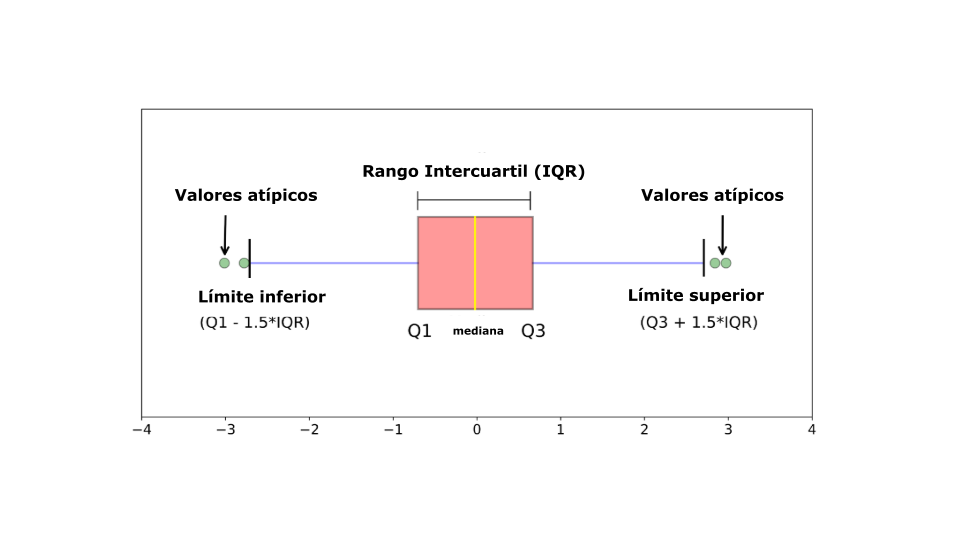

Si observamos el diagrama de caja de la variable price .

In [ ]:
# Diagrama de caja
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(15, 3))
reseVinoArgChi_df['price'].plot(kind='box',vert=False , ax=ax)
ax.set_title("Diagrama de caja (Box Plot) para 'price'")


Se observan valores atípicos pero ¿cuáles son?.

Para responder esta pregunta identifiquemos el valor de los bigotes del diagrama, que actúan como límites. Para calcularlos, veamos el método por Rango Intercuartil (Interquartile Range, IQR).

In [ ]:
Q1 = reseVinoArgChi_df['price'].quantile(0.25) # Calcular cuartíles
Q3 = reseVinoArgChi_df['price'].quantile(0.75)

print("Valores atípicos en 'price' por IQR:")

IQR = Q3 - Q1 # Calcular Rango intercuartil
print("Cuartil Q1:",Q1)
print("Cuartil Q3:",Q3)
print("Rango intercuartil :",IQR)

limite_inferior = Q1 - 1.5 * IQR #
limite_superior = Q3 + 1.5 * IQR
print("Limite inferior :",limite_inferior)
print("Limite superior :",limite_superior)

# Detectar valores atípicos
atipicos_IQR_df = reseVinoArgChi_df[(reseVinoArgChi_df['price'] < limite_inferior) | (reseVinoArgChi_df['price'] > limite_superior)]


atipicos_IQR_df['price'].sort_values()


Analizando solo la variable price. Se identifica por método IQR, que los precios de botella de vino de Argentina y Chile superiores a 39 USD son valores atípicos.

#### Método de puntuación Z (Z-score)


In [ ]:
from sklearn.preprocessing import StandardScaler # importar librería
import numpy as np

# Normalizar para luego aplicar el filtro por el umbral

escalado_puntoZ = StandardScaler() # Instanciar la clase StandardScaler

reseVinoArgChi_df['Z_price'] = escalado_puntoZ.fit_transform( # Entrenar y transformar. Nueva variable
    reseVinoArgChi_df[['price']]
    )

print('Media {} y desvío estándar {} utilizados '. format(escalado_puntoZ.mean_[0], np.sqrt(escalado_puntoZ.var_)[0]))


z_umbral = 3 # Setear umbral de puntaje z


# Identificar valor atípico
atipicos_estandar_df = reseVinoArgChi_df.loc[(reseVinoArgChi_df['Z_price']< -(z_umbral)) | (reseVinoArgChi_df['Z_price']> z_umbral),]

# Imprimir resultados
display("Atipicos en 'point' por puntaje Z :",atipicos_estandar_df[['price','Z_price']].sort_values(by='Z_price'))

 Se identifica por método de puntuación Z, que los precios de botella de vino de Argentina y Chile superiores a 92 USD son valores atípicos.

Si graficamos las puntuaciones Z para cada observación

In [ ]:
# Crear gráfica
fig, ax = plt.subplots(figsize=(15, 3))
ax.scatter(reseVinoArgChi_df['price'] , reseVinoArgChi_df['Z_price'] , color='blue', label='Z-Scores')
ax.set_title("Puntajes Z (Z-Scores) para 'price'")
plt.axhline(y=z_umbral, color='red', linestyle='--', label='Umbral')
plt.legend()

En este gráfico de dispersión de puntuaciones Z, cada punto representa la puntuación Z de un punto de datos individual. La línea discontinua roja indica el umbral de puntuación Z elegido (en este caso, 3). Los valores atípicos se identifican como puntos por encima de este umbral, que para el ejemplo son los mayores de 92 USD.



#### Eliminación de valores atípicos


Si utilizamos el método IQR para eliminar valores atípicos en ‘price’, luego identificamos estadísticas y visualizamos su diagrama de caja.

In [ ]:
# Seleccionar price dentro de los limites de IQR
datos_sinAtipicos_IQR_df = reseVinoArgChi_df[(reseVinoArgChi_df['price'] >= limite_inferior) & (reseVinoArgChi_df['price']  <= limite_superior)]
display("Estadística para 'price' con valores atípicos ",reseVinoArgChi_df['price'] .describe())
display("Estadística para 'price' sin valores atípicos por IQR ",datos_sinAtipicos_IQR_df['price'].describe())


In [ ]:
8172-902

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3))
reseVinoArgChi_df['price'].plot(kind='box',vert=False , ax=axs[0])
axs[0].set_title("Diagrama de caja (Box Plot) para 'price'")
datos_sinAtipicos_IQR_df['price'].plot(kind='box',vert=False , ax=axs[1])
axs[1].set_title("Diagrama de caja (Box Plot) para 'price' sin valores atípicos")

Observamos que se mejora la visualización de la distribución de los valores en el diagrama de caja, se identifica la mediana, Q1 y Q3. Pero aún eliminando los valores atípicos, siguen estando. Nosotros hasta aquí presentamos un análisis de valores atípicos univariados. Por los que antes de eliminar los valores atípicos, es necesario explorar su relación con otras variables.

Por otro lado, al eliminar valores atípicos de la variable ‘price’, alteramos su distribución. Explorando su distribución mediante histograma, ahora la gráfica es clara  e identifica menos asimetría.

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15, 3))
reseVinoArgChi_df['price'].plot(kind='hist', bins = 10, ax=axs[0])
axs[0].set_title("Histograma para 'price'")
datos_sinAtipicos_IQR_df['price'].plot(kind='hist',  bins = 10, ax=axs[1])
axs[1].set_title("Histograma para 'price' sin valores atípicos")

Si complementamos estás gráficas con resúmenes estadísticos, se observa claramente el cambio de valor de la media  (de 22 a 16 USD), de la desviación estándar (22 a 6 USD) y del máximo (400 a 39 USD) de price.

En esta primera instancia, dado que solo se exploró una sola variable, sería conveniente no elimnar datos.
Terminemos de explorar las otras variables, observemos relaciones y entendamos mejor los datos.

📝 **Ejercicio**

En base al objeto Dataframe reseVinoArgChi_df


In [ ]:
reseVinoArgChi_df.head(5)

* Identificar los valores atípicos de puntos (points) mediante un diagrama de caja

* Mostrar los valores atípicos indetificados por método IQR

**Haz doble click para ver la respuesta**
<!--

fig, ax = plt.subplots(figsize=(15, 3))
ax.boxplot(reseVinoArgChi_df[['points']], vert=False)
ax.set_title("Diagrama de caja (Box Plot) para 'price'")

# Calcular cuartíles
Q1 = reseVinoArgChi_df['points'].quantile(0.25)
Q3 = reseVinoArgChi_df['points'].quantile(0.75)

# Calcular rango intercualtílico
IQR = Q3 - Q1

# Calcular límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Detectar valores atípicos
atipicos_IQR_df = reseVinoArgChi_df[(reseVinoArgChi_df['points'] < limite_inferior) | (reseVinoArgChi_df['points'] > limite_superior)]

# Imprimir resultados
print("Atipicos en 'points' por IQR:")
atipicos_IQR_df['points']
-->